# GPR Model Training (GPFlow)
https://www.gpflow.org/

In [1]:
import os
import csv
import pandas as pd
import gpflow
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

## Preprocessing

In [2]:
n4_data = pd.read_excel('../../data/boron_coord_final.xlsx')

n4_data = n4_data.dropna(subset='%')

In [3]:
other = ['Cr2O3', 'HfO2', 'PbO', 'UO3', 'Y2O3','ZrO2','Fe2O3',
         'P2O5', 'TiO2', 'CoO','SrO','Cs2O','Bi2O3','BaO','SO3','La2O3']
oxEl = ['Al2O3','B2O3','CaO','K2O','Li2O','MgO','Na2O','SiO2',
 'ZnO','Rb2O']

n4_data['other'] = n4_data[other].sum(axis=1)
class_cols = oxEl + ['other']

X = n4_data[ class_cols ].fillna(0)
y = pd.DataFrame(n4_data['%'])

In [4]:
X_train_df, X_test_df, y_train_df, y_test_df = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train_df.to_numpy()
X_test = X_test_df.to_numpy()

y_train = y_train_df.to_numpy()
y_test = y_test_df.to_numpy()

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train) 
y_train_scaled = y_scaler.fit_transform(y_train)

X_test_scaled = x_scaler.transform(X_test)
y_test_scaled = y_scaler.transform(y_test)

## KFold Cross Validation

In [5]:
kernels = {'Matern12':gpflow.kernels.Matern12(), 
            'Matern32':gpflow.kernels.Matern32(),
            'Matern52':gpflow.kernels.Matern52(), 
            'Linear': (gpflow.kernels.Linear()* gpflow.kernels.RBF(lengthscales=1))}

kf = KFold(n_splits=5, shuffle=True, random_state=42)


In [6]:
filename = 'gpflow_kernel_tuning.csv'

if not os.path.exists(f'./{filename}'):
    with open(filename, 'w', newline='') as file:
        writer = csv.DictWriter(file, fieldnames = ['kernel', 'r2', 'rmse'])
        writer.writeheader()

    for key, kernel in kernels.items(): 
        r2 = []
        rmse = []
        y_kscaler = StandardScaler()
        X_kscaler =StandardScaler()
        for fold_idx, (train_index, test_index) in enumerate(kf.split(X_train, y_train)):
            X_ktrain = X_train[train_index]
            X_ktest = X_train[test_index]
            X_kscaler.fit(X_ktrain.reshape(-1,1))
            X_ktrain_scaled = X_kscaler.transform(X_ktrain.reshape(-1, 1)).reshape( X_ktrain.shape)
            X_ktest_scaled = X_kscaler.transform(X_ktest.reshape(-1, 1)).reshape( X_ktest.shape)

            y_ktrain = y_train[train_index]
            y_ktest = y_train[test_index]
            y_kscaler.fit(y_ktrain.reshape(-1,1))
            y_ktrain_scaled = y_kscaler.transform(y_ktrain.reshape(-1, 1)).reshape( y_ktrain.shape)
            y_ktest_scaled = y_kscaler.transform(y_ktest.reshape(-1, 1)).reshape( y_ktest.shape)

            model = gpflow.models.GPR((X_ktrain_scaled, y_ktrain_scaled), kernel=kernel)
            opt = gpflow.optimizers.Scipy()
            opt.minimize(model.training_loss, model.trainable_variables)
            y_pred_scaled, var = model.predict_f(X_ktest_scaled)
            
            y_pred = y_kscaler.inverse_transform(y_pred_scaled.numpy().reshape(-1, 1)).reshape(y_pred_scaled.shape)
            y_pred = np.maximum(y_pred, 0)
            
            r2_k = r2_score(y_ktest, y_pred)
            rmse_k = root_mean_squared_error(y_ktest, y_pred)

            r2.append(r2_k)
            rmse.append(rmse_k)

            dict = {'kernel': key,
            'r2': r2_k,
            'rmse': rmse_k}

            with open(filename, 'a', newline='') as file:
                writer = csv.DictWriter(file, fieldnames = dict.keys())
                writer.writerow(dict)

        dict = {'kernel': f'{key}_average',
                'r2': sum(r2)/len(r2),
                'rmse': sum(rmse)/len(rmse)}
        
        with open(filename, 'a', newline='') as file:
            writer = csv.DictWriter(file, fieldnames = dict.keys())
            writer.writerow(dict)

In [7]:
filename = 'gpflow_kernel_tuning.csv'

print("\nSELECTING BEST kernel FROM TUNING RESULTS:")

try:
    # Step 1: Read the CSV file
    df = pd.read_csv(filename)

    # Step 2: Filter rows where kernels are NOT averages (you can include averages or exclude them)
    df_filtered = df[df["kernel"].astype(str).str.contains('average')]
    
    # Step 3: Define the performance metric for selecting the best kernel
    best_row = df_filtered.loc[df_filtered['r2'].idxmax()]  # Choose row with the highest accuracy
    # Alternatively, minimize RMSE:
    # best_row = df_filtered.loc[df_filtered['rmse'].idxmin()] 
    
    # Save best kernel for the model
    best_kernel = kernels[best_row['kernel'].replace('_average','')]  # Extract the kernel
    
    # Extract performance metrics
    best_r2 = best_row['r2']
    best_rmse = best_row['rmse']
    
    # Print the best kernel and performance metrics
    print("Best Kernel:")
    print(f"  Kernel: {best_kernel}")
    print("Performance:")
    print(f"  R²: {best_r2}")
    print(f"  RMSE: {best_rmse}")

except Exception as e:
    # Handle errors gracefully
    print(f"Error processing kernel tuning results: {str(e)}")


SELECTING BEST kernel FROM TUNING RESULTS:
Best Kernel:
  Kernel: <gpflow.kernels.stationaries.Matern32 object at 0x0000027EAF9425F0>
Performance:
  R²: 0.8494033037519981
  RMSE: 8.258591656369367


## Train Model

In [8]:
model = gpflow.models.GPR((X_train_scaled, y_train_scaled), kernel=best_kernel)
opt = gpflow.optimizers.Scipy()
opt.minimize(model.training_loss, model.trainable_variables)
y_pred_scaled, var = model.predict_y(X_test_scaled)

In [9]:
#determining r2 and rmse 
y_pred = y_scaler.inverse_transform(y_pred_scaled.numpy().reshape(-1, 1)).reshape(y_pred_scaled.shape)
y_pred = np.maximum(y_pred, 0)

# Compute metrics
r2 = r2_score(y_test_df, y_pred)
rmse =root_mean_squared_error(y_test_df, y_pred)

print(round(r2,3),round(rmse,3))

0.88 7.473


In [10]:
y_pred_test = y_pred.flatten()
y_pred_test_var = y_scaler.inverse_transform(var.numpy().reshape(-1,1).reshape(var.shape))

In [11]:
y_pred_train_mean, y_pred_train_var_scaled = model.predict_y(X_train_scaled)
y_pred_train = y_scaler.inverse_transform(y_pred_train_mean.numpy().reshape(-1, 1)).reshape(y_pred_train_mean.shape)
y_pred_train_var = y_scaler.inverse_transform(y_pred_train_var_scaled.numpy().reshape(-1,1).reshape(y_pred_train_var_scaled.shape))# Compute metrics
r2_train = r2_score(y_train, y_pred_train)
rmse_train =root_mean_squared_error(y_train, y_pred_train)

print(round(r2_train,3),round(rmse_train,3))

0.921 6.094


## Save Model Results 

In [12]:
# Create prediction results for each model
# Dictionary to store all model predictions
model_results = {}

# Get predictions for all models


# Training predictions
# train_preds, train_var_pred = model.predict_y(X_train)
y_pred_train_mean = np.maximum(y_pred_train, 0)
train_df = pd.DataFrame({
    'y_true': y_train.flatten(),
    'y_pred': y_pred_train_mean.flatten(),
    'var_pred': np.sqrt(y_pred_train_var.flatten()),
    'is_train': 1
}, index=y_train_df.index)

# Test predictions
# test_preds, var_pred = model.predict(X_test_scaled, return_std=True)
# test_preds = np.maximum(test_preds, 0)

test_df = pd.DataFrame({
    'y_true': y_test.flatten(),
    'y_pred': y_pred_test.flatten(),
    'var_pred': np.sqrt(y_pred_test_var.flatten()),
    'is_train': 0
}, index=y_test_df.index)

# Combine train and test results
results_df = pd.concat([train_df, test_df])

# Join with Glass ID from the original dataset
# Join with glass ID
full_results = n4_data['Glass Name'].to_frame().join(results_df, how='left')

# Rename column to match your original format
full_results.rename(columns={'Glass Name': 'glass_name'}, inplace=True)

# Store back in the dictionary
results_df = full_results

# # Save results to CSV files
results_df.to_csv(f"../results/regression/gpflow_cr_results.csv")

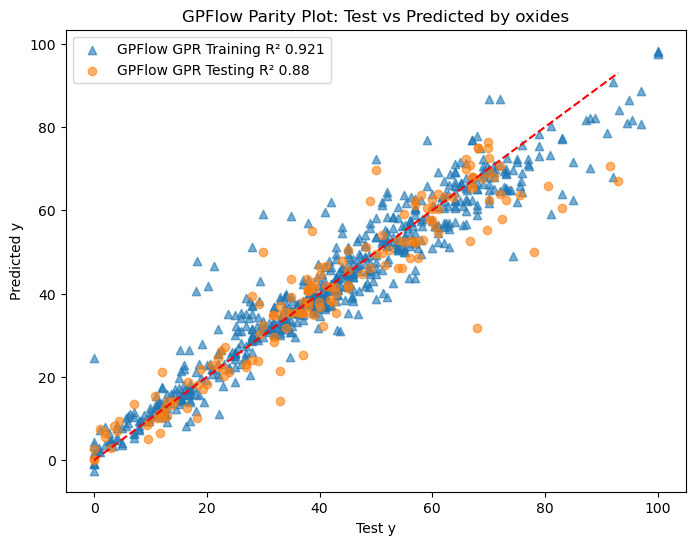

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(y_train,y_pred_train, alpha=0.6, label=f'GPFlow GPR Training R\u00B2 {round(r2_train,3)}', marker = '^')
plt.scatter(y_test,y_pred, alpha=0.6, label=f'GPFlow GPR Testing R\u00B2 {round(r2,3)}')

plt.plot([np.min(y_test), np.max(y_test)], [np.min(y_test), np.max(y_test)], 'r--')  # Ideal line
plt.xlabel("Test y")
plt.ylabel("Predicted y")
plt.title("GPFlow Parity Plot: Test vs Predicted by oxides")
plt.legend()
plt.show()

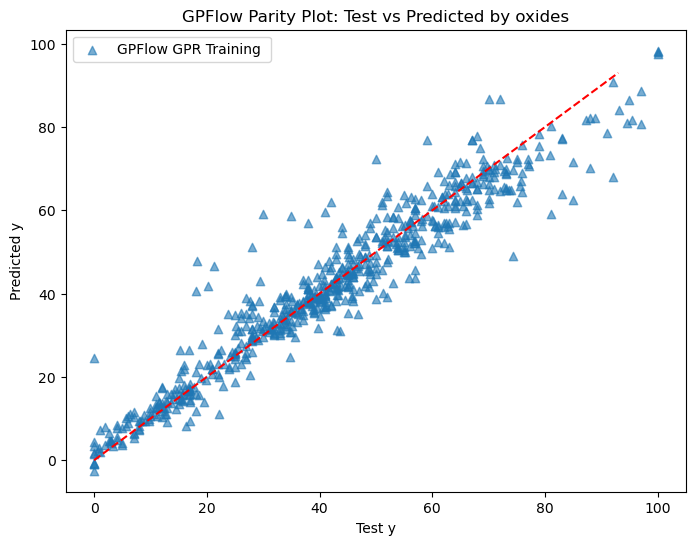

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(y_train,y_pred_train, alpha=0.6, label=f'GPFlow GPR Training ', marker = '^')
plt.plot([np.min(y_test), np.max(y_test)], [np.min(y_test), np.max(y_test)], 'r--')  # Ideal line
plt.xlabel("Test y")
plt.ylabel("Predicted y")
plt.title("GPFlow Parity Plot: Test vs Predicted by oxides")
plt.legend()
plt.show()

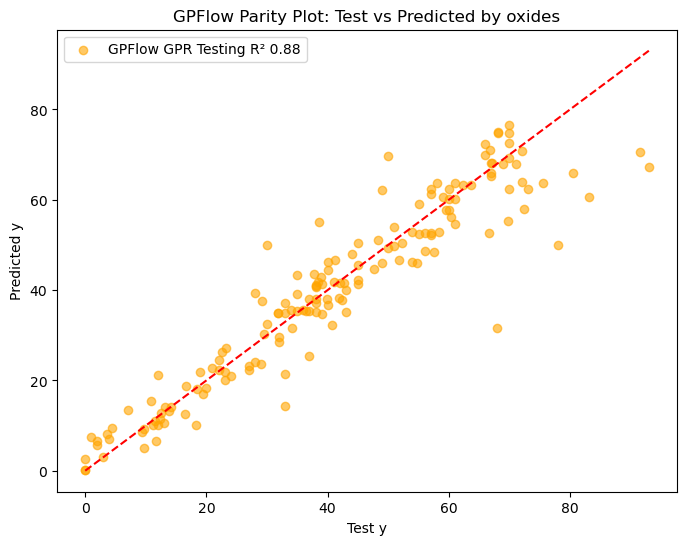

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred, alpha=0.6, label=f'GPFlow GPR Testing R\u00B2 {round(r2,3)}', c='orange')

plt.plot([np.min(y_test), np.max(y_test)], [np.min(y_test), np.max(y_test)], 'r--')  # Ideal line
plt.xlabel("Test y")
plt.ylabel("Predicted y")
plt.title("GPFlow Parity Plot: Test vs Predicted by oxides")
plt.legend()
plt.show()

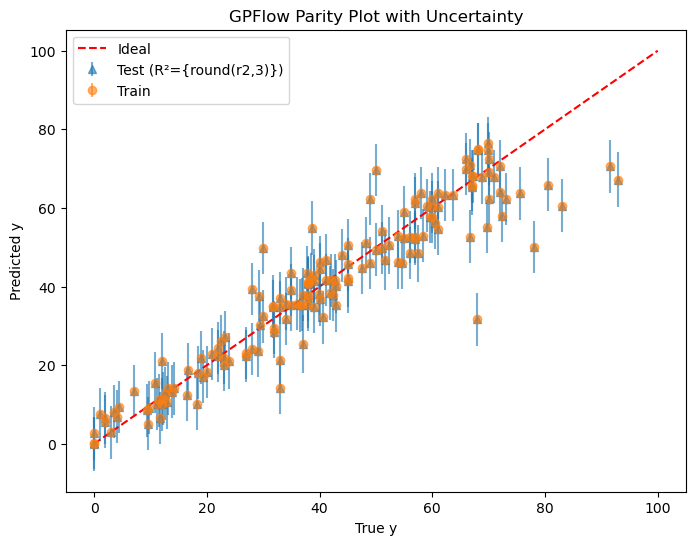

In [19]:
# plot both training and testing predicted vs measured figures, add error bars
plt.figure(figsize=(8,6))

# Train data with error bars
plt.errorbar(
    y_test, y_pred_test.flatten(), 
    yerr=np.sqrt(y_pred_test_var.flatten()), 
    fmt='^', alpha=0.6, label='Test (R²={round(r2,3)})'
)

plt.errorbar(
    y_test, y_pred_test.flatten(), 
    yerr=np.sqrt(var.numpy().flatten()), 
    fmt='o', alpha=0.6, label=f'Train'
)



# 1-to-1 line
min_val = min(np.min(y_train), np.min(y_test))
max_val = max(np.max(y_train), np.max(y_test))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Ideal")
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("GPFlow Parity Plot with Uncertainty")
plt.legend()
plt.show()

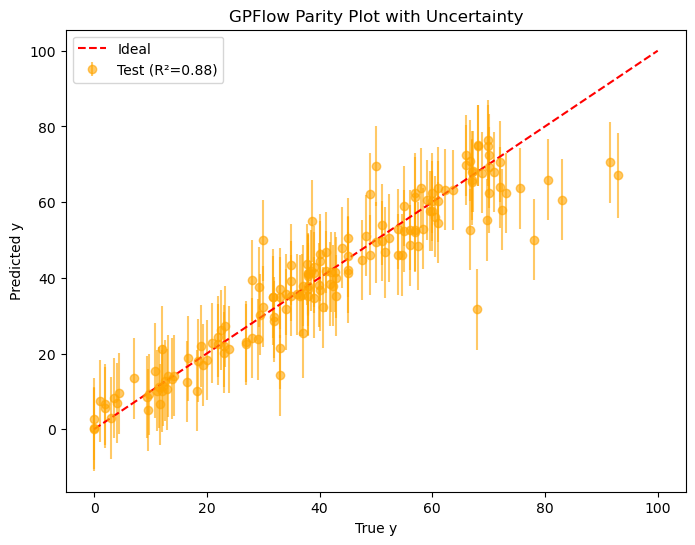

In [18]:
# plot both training and testing predicted vs measured figures, add error bars
plt.figure(figsize=(8,6))
plt.errorbar(
    y_test, y_pred_test.flatten(), 
    yerr= np.sqrt(y_pred_test_var.flatten())*1.6, 
    fmt='o', alpha=0.6, label=f'Test (R²={round(r2,3)})',
    c='orange'
)

# 1-to-1 line
min_val = min(np.min(y_train), np.min(y_test))
max_val = max(np.max(y_train), np.max(y_test))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Ideal")
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("GPFlow Parity Plot with Uncertainty")
plt.legend()
plt.show()